# Etapa 3 — Precios por Provincia

Este notebook inicia el análisis territorial utilizando los datasets ya integrados y procesados al final de la Etapa 2:

- `productos_dia_geo.parquet`
- `productos_carrefour_geo.parquet`

Estos archivos contienen exclusivamente:
- los **productos comunes** entre DIA y Carrefour,
- las **sucursales normalizadas**,
- y las **ocho provincias coincidentes** previamente verificadas.

La etapa 3 incorpora la dimensión provincial al análisis de precios y se desarrolla sobre el universo producto–sucursal ya depurado.  
Aquí se estudiará:

- la comparación de precios entre cadenas dentro de cada provincia;
- la variabilidad territorial de los precios;
- diferencias entre provincias para los mismos productos;
- análisis de precios de lista y precios efectivos en contexto geográfico;
- preparación de visualizaciones y agregaciones provinciales.

Este notebook continúa el flujo incremental del proyecto sin volver a cargar los datasets originales de gran tamaño, utilizando únicamente los resultados procesados y listos para el análisis territorial.

## 1. Carga de datos

En esta sección se cargan los datasets procesados generados al final de la Etapa 2.  
Estos archivos contienen la integración producto–sucursal ya filtrada por las ocho provincias comunes y constituyen el punto de partida para el análisis territorial.

Se cargan los archivos Parquet y se realiza una inspección inicial de su estructura para verificar que las columnas relevantes estén presentes y que los datos se encuentren en condiciones adecuadas para continuar con el procesamiento.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
# Cargamos los datasets geográficos procesados (producto–sucursal) generados en la Etapa 2
productos_dia_geo = pd.read_parquet('../data/processed/productos_dia_geo.parquet')
productos_carrefour_geo = pd.read_parquet('../data/processed/productos_carrefour_geo.parquet')

print("DIA:", productos_dia_geo.shape)
print("Carrefour:", productos_carrefour_geo.shape)
print("Provincias:", sorted(productos_dia_geo['provincia'].unique()))

DIA: (2558165, 10)
Carrefour: (835700, 10)
Provincias: ['BUENOS AIRES', 'CABA', 'CORDOBA', 'CORRIENTES', 'ENTRE RIOS', 'JUJUY', 'SALTA', 'SANTA FE']


In [54]:
# Inspeccionamos los primeros registros del dataset de Carrefour
productos_carrefour_geo.head(3)

,id_sucursal,id_producto,productos_descripcion,productos_marca,precio_efectivo,provincia,sucursales_localidad,sucursales_latitud,sucursales_longitud,id_comercio
0,873,7791293047102,SHAMPOO RECONSTRUCCION COMPLETA DOVE X 400 CC,DOVE,9889.0,CORDOBA,Córdoba,-31.425366,-64.187647,10
1,709,7791337010598,POSTRE CHOCOLATE DANETTE PACK 2 X 95 GRS,DANETTE,4735.0,BUENOS AIRES,Loma Hermosa,-34.562258,-58.600613,10
2,120,7790040173200,GALLETITAS KESITAS ESTUCHE X 125 GRS,KESITAS,2245.0,CABA,Ciudad Autónoma de Buenos Aires,-34.558821,-58.459349,10


In [55]:
# Inspeccionamos los primeros registros del dataset de DIA
productos_dia_geo.head(3)

,id_sucursal,id_producto,productos_descripcion,productos_marca,precio_efectivo,provincia,sucursales_localidad,sucursales_latitud,sucursales_longitud,id_comercio
0,1,0000040084107,HUEVO DE CHOCOLATE,KINDE,2785.0,CABA,CAPITAL FEDERAL,-34.5971373,-58.4976429,15
1,1,0000042277057,CREM FACIAL CUID NUT,NIVEA,6455.0,CABA,CAPITAL FEDERAL,-34.5971373,-58.4976429,15
2,1,0000075079437,ANTITRANS CREM WOMEN,DOVE,12750.0,CABA,CAPITAL FEDERAL,-34.5971373,-58.4976429,15


## 2. Limpieza y control de calidad

Antes de avanzar con el análisis territorial, se realiza una depuración inicial sobre los datasets cargados.  
Las tareas incluidas en esta sección son:

- identificación de valores nulos en columnas relevantes;
- verificación de la cantidad de productos presentes en cada cadena;
- recalculo del universo de productos comunes dentro del territorio filtrado;
- filtrado de los datasets para conservar únicamente los productos coincidentes;
- resolución de valores faltantes en `productos_marca` para DIA utilizando la información disponible en Carrefour;
- verificación final de consistencia.

Este paso garantiza que ambos datasets queden completamente alineados y listos para las agregaciones y comparaciones provinciales que se desarrollarán en las siguientes secciones.


In [56]:
# Verificamos si hay valores nulos.
productos_carrefour_geo.isnull().sum()

id_sucursal              0
id_producto              0
productos_descripcion    0
productos_marca          0
precio_efectivo          0
provincia                0
sucursales_localidad     0
sucursales_latitud       0
sucursales_longitud      0
id_comercio              0
dtype: int64

In [57]:
# Verificamos si hay valores nulos.
productos_dia_geo.isnull().sum()

id_sucursal                  0
id_producto                  0
productos_descripcion        0
productos_marca          13748
precio_efectivo              0
provincia                    0
sucursales_localidad         0
sucursales_latitud           0
sucursales_longitud          0
id_comercio                  0
dtype: int64

Hay 13748 registros nulos en la columna `productos_marca` del comercio DIA, se deberá resolver para poder continuar con todos los datos completos.

In [58]:
# Identificar productos presentes en DIA y Carrefour dentro del territorio filtrado
productos_dia_ids = set(productos_dia_geo['id_producto'])
productos_carrefour_ids = set(productos_carrefour_geo['id_producto'])

print("Productos totales en DIA:", len(productos_dia_ids))
print("Productos totales en Carrefour:", len(productos_carrefour_ids))

Productos totales en DIA: 2646
Productos totales en Carrefour: 2645


In [59]:
# Recalcular productos realmente comunes (al menos una aparición en cada cadena)
productos_comunes_geo = productos_dia_ids.intersection(productos_carrefour_ids)

print("Productos comunes (territorio filtrado):", len(productos_comunes_geo))

Productos comunes (territorio filtrado): 2645


In [60]:
# Filtrar ambos datasets al universo común
productos_dia_geo = productos_dia_geo[productos_dia_geo['id_producto'].isin(productos_comunes_geo)].copy()
productos_carrefour_geo = productos_carrefour_geo[productos_carrefour_geo['id_producto'].isin(productos_comunes_geo)].copy()

# Ver cuántos productos quedaron fuera de la selección común
productos_fuera_dia = productos_dia_ids - productos_comunes_geo
productos_fuera_carrefour = productos_carrefour_ids - productos_comunes_geo

print("Productos fuera de DIA:", len(productos_fuera_dia))
print("Productos fuera de Carrefour:", len(productos_fuera_carrefour))

Productos fuera de DIA: 1
Productos fuera de Carrefour: 0


Luego de filtrar y dejar sólo los productos comunes en ambas cadenas, vemos que sólo 1 producto queda afuera del análisis de los 2646 productos coincidentes en ambas sucursales que arrancaron en la etapa 1 del proyecto.
Ahora queda completar los valores nulos existentes en `productos_marca` en DIA por los de Carrefour.

In [61]:
# Extraemos una marca por producto desde Carrefour (una fila por id_producto)
carrefour_marcas = (
    productos_carrefour_geo[['id_producto', 'productos_marca']]
    .drop_duplicates('id_producto')
    .set_index('id_producto')['productos_marca']
)

# Filtramos solo los nulos de DIA
mask_nulos = productos_dia_geo['productos_marca'].isna()

# Completamos únicamente esos nulos
productos_dia_geo.loc[mask_nulos, 'productos_marca'] = (
    productos_dia_geo.loc[mask_nulos, 'id_producto'].map(carrefour_marcas)
)

# 6. Verificación final
print("Verificación final:")
print("\nNulos:", productos_dia_geo['productos_marca'].isna().sum())

Verificación final:

Nulos: 0


## 3. Preparación de tipos y estructura para el análisis territorial

Con los productos comunes ya depurados y las marcas completadas, se ajustan los tipos de datos y la estructura de las columnas necesarias para el análisis provincial.  
Este paso incluye:

- conversión de columnas numéricas a sus tipos adecuados;
- verificación de claves (`id_producto`, `id_sucursal`);
- normalización de columnas categóricas.

Estos ajustes preparan los datos para que los cálculos posteriores que se realicen sean sobre datos consistentes y correctamente tipados.


In [62]:
productos_dia_geo.dtypes


id_sucursal                  str
id_producto                  str
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud           str
sucursales_longitud          str
id_comercio                  str
dtype: object

In [63]:
# Conversión de columnas numéricas a sus tipos adecuados en DIA

# Convertimos identificadores a enteros
productos_dia_geo['id_sucursal'] = productos_dia_geo['id_sucursal'].astype('int64')
productos_dia_geo['id_comercio'] = productos_dia_geo['id_comercio'].astype('int64')
productos_dia_geo['id_producto'] = productos_dia_geo['id_producto'].astype('int64')

# Convertimos coordenadas a float
productos_dia_geo['sucursales_latitud'] = productos_dia_geo['sucursales_latitud'].astype('float64')
productos_dia_geo['sucursales_longitud'] = productos_dia_geo['sucursales_longitud'].astype('float64')

# Verificación final de tipos
productos_dia_geo.dtypes


id_sucursal                int64
id_producto                int64
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud       float64
sucursales_longitud      float64
id_comercio                int64
dtype: object

Se convierten los identificadores (`id_sucursal`, `id_comercio`, `id_producto`) a enteros y las coordenadas (`sucursales_latitud`, `sucursales_longitud`) a valores numéricos.  
Con esto se asegura que las claves y las variables geográficas tengan el tipo adecuado para las operaciones y análisis posteriores.  
Luego de la conversión se verifica la estructura final del dataset y se procede a aplicar los mismos cambios en el dataset de Carrefour.


In [64]:
productos_carrefour_geo.dtypes

id_sucursal                  str
id_producto                  str
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud       float64
sucursales_longitud      float64
id_comercio                  str
dtype: object

In [65]:
# Conversión de columnas numéricas a sus tipos adecuados en Carrefour

# Convertimos identificadores a enteros
productos_carrefour_geo['id_sucursal'] = productos_carrefour_geo['id_sucursal'].astype('int64')
productos_carrefour_geo['id_comercio'] = productos_carrefour_geo['id_comercio'].astype('int64')
productos_carrefour_geo['id_producto'] = productos_carrefour_geo['id_producto'].astype('int64')

# Verificación final de tipos
productos_carrefour_geo.dtypes

id_sucursal                int64
id_producto                int64
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud       float64
sucursales_longitud      float64
id_comercio                int64
dtype: object

In [66]:
# Verificación de duplicados de claves id_producto-id_sucursal en DIA
productos_dia_geo[['id_producto', 'id_sucursal']].duplicated().sum()

np.int64(0)

In [67]:
# Verificación de duplicados de claves id_producto-id_sucursal en Carrefour
productos_carrefour_geo[['id_producto', 'id_sucursal']].duplicated().sum()

np.int64(0)

In [68]:
import unicodedata

def quitar_tildes(texto):
    if isinstance(texto, str):
        return ''.join(
            c for c in unicodedata.normalize('NFD', texto)
            if unicodedata.category(c) != 'Mn'
        )
    return texto


In [69]:
# Normalización de la columna `sucursales_localidad` en DIA
productos_dia_geo['sucursales_localidad'] = (
    productos_dia_geo['sucursales_localidad']
    .str.strip()
    .str.upper()
    .apply(quitar_tildes)
)

# Normalización de la columna `sucursales_localidad` en Carrefour
productos_carrefour_geo['sucursales_localidad'] = (
    productos_carrefour_geo['sucursales_localidad']
    .str.strip()
    .str.upper()
    .apply(quitar_tildes)
)

Se normaliza la columna `sucursales_localidad` eliminando espacios, unificando mayúsculas y quitando tildes para asegurar consistencia en las agrupaciones y comparaciones territoriales.


## 3. Evaluación y selección de productos comparables en todas las provincias

Para construir un conjunto de productos estrictamente homogéneo entre cadenas y provincias, se identifican los productos que cumplen simultáneamente dos condiciones:

1. **Presencia en ambas cadenas dentro de cada provincia**, garantizando que exista precio comparable.
2. **Disponibilidad en las ocho provincias coincidentes**, evitando diferencias de composición territorial.

Se calcula la cobertura producto–provincia y se determina cuántos productos mantienen comparabilidad plena en todo el territorio. Este criterio es más restrictivo, pero asegura un conjunto de productos consistente y metodológicamente sólido para el análisis provincial.


In [70]:
# Calculamos el precio promedio por producto y provincia para DIA y Carrefour
precio_dia = (productos_dia_geo
    .groupby(['provincia', 'id_producto'])['precio_efectivo'].mean().rename('precio_dia_prov'))
precio_carrefour = (productos_carrefour_geo
    .groupby(['provincia', 'id_producto'])['precio_efectivo'].mean().rename('precio_carrefour_prov'))

In [71]:
# Unimos los precios promedio por producto y provincia de ambas cadenas, 
# eliminando los pares que no tengan precio en ambas
pares = pd.concat([precio_dia, precio_carrefour], axis=1).dropna().reset_index()
print("Pares producto-provincia con precio en ambas cadenas:", len(pares))

Pares producto-provincia con precio en ambas cadenas: 19368


In [72]:
# Calculamos la cobertura de productos según en cuántas provincias son comparables
cobertura = pares.groupby('id_producto')['provincia'].nunique()
print("\nDistribución de productos según en cuántas provincias son comparables:")
print(cobertura.value_counts().sort_index().to_string())


Distribución de productos según en cuántas provincias son comparables:
provincia
1      11
2      53
3      19
4      43
5      64
6     146
7     646
8    1663


De los 2.645 productos comunes, **1.663 están disponibles en ambas cadenas en las ocho provincias** y 646 lo están en siete. El resto se distribuye en coberturas menores.

Exigir presencia en las ocho provincias conserva el 62,8% del universo de productos comunes. Es una pérdida aceptable a cambio de una comparación estrictamente homogénea, y conserva un universo amplio de productos comparables.

## 4. Construcción del dataset final de productos comparables en las ocho provincias

A partir de los productos con cobertura completa identificados en el punto anterior, se genera un dataset consolidado que conserva todas las columnas originales de DIA y Carrefour, incorporando además los precios promedios por provincia para cada cadena. Este conjunto representa los 1.663 productos plenamente comparables en todo el territorio y constituye la base para las etapas posteriores de análisis, etiquetado y modelado.

In [73]:
# Seleccionamos los productos que son comparables en todas las 8 provincias
productos_cobertura_8 = cobertura[cobertura == 8].index
len(productos_cobertura_8)

1663

In [74]:
# Filtrar DIA y Carrefour solo a esos productos
dia_8 = productos_dia_geo[productos_dia_geo['id_producto'].isin(productos_cobertura_8)].copy()
carrefour_8 = productos_carrefour_geo[productos_carrefour_geo['id_producto'].isin(productos_cobertura_8)].copy()

In [75]:
# Incorporar los precios promedio al dataset original filtrado
dia_8 = dia_8.merge(precio_dia, on=['provincia', 'id_producto'], how='left')
carrefour_8 = carrefour_8.merge(precio_carrefour, on=['provincia', 'id_producto'], how='left')

In [76]:
# Añadir columna de cadena y unir ambos datasets
dia_8['cadena'] = 'DIA'
carrefour_8['cadena'] = 'CARREFOUR'

productos_comunes_8 = pd.concat([dia_8, carrefour_8], ignore_index=True)

# 6. Verificación final

print("Productos únicos:", productos_comunes_8['id_producto'].nunique())
print("Provincias únicas:", productos_comunes_8['provincia'].nunique())
print("Columnas:", productos_comunes_8.columns.tolist())


Productos únicos: 1663
Provincias únicas: 8
Columnas: ['id_sucursal', 'id_producto', 'productos_descripcion', 'productos_marca', 'precio_efectivo', 'provincia', 'sucursales_localidad', 'sucursales_latitud', 'sucursales_longitud', 'id_comercio', 'precio_dia_prov', 'cadena', 'precio_carrefour_prov']


El dataset `productos_comunes_8` consolida toda la información relevante de DIA y Carrefour para los 1.663 productos con cobertura completa en las ocho provincias. 

En esta etapa se incorporaron los precios promedio provinciales de cada cadena (`precio_dia_prov` y `precio_carrefour_prov`) y se añadió la columna `cadena` para identificar el origen de cada registro. Además, se conservaron todas las columnas originales —descripción, marca, coordenadas, claves y precios individuales por sucursal— lo que permite utilizar este conjunto tanto para el análisis territorial como para las etapas de etiquetado y modelado basadas en NLP.

Con esta estructura unificada y homogénea, `productos_comunes_8` queda preparado para continuar con los análisis comparativos entre provincias, la construcción de la canasta final y el desarrollo del modelo de clasificación de rubros.

## 5. Distribución territorial de sucursales por cadena y provincia

Antes de avanzar con el análisis territorial de precios, es necesario evaluar la estructura geográfica de cada cadena. La cantidad de sucursales por provincia determina el nivel de dispersión territorial y la representatividad de los precios promedios utilizados en la comparación.

A partir del dataset unificado `productos_comunes_8`, se calcula el número de sucursales únicas por cadena y por provincia dentro del universo de productos comparables en las ocho jurisdicciones.

In [87]:
productos_comunes_8.groupby('cadena')['id_sucursal'].nunique()


cadena
CARREFOUR    633
DIA          982
Name: id_sucursal, dtype: int64

In [84]:
productos_comunes_8.groupby(['provincia', 'cadena'])['id_sucursal'].nunique()

provincia     cadena   
BUENOS AIRES  CARREFOUR    160
              DIA          428
CABA          CARREFOUR    365
              DIA          432
CORDOBA       CARREFOUR     82
              DIA            3
CORRIENTES    CARREFOUR      2
              DIA           15
ENTRE RIOS    CARREFOUR     12
              DIA           65
JUJUY         CARREFOUR      1
              DIA            6
SALTA         CARREFOUR      5
              DIA           24
SANTA FE      CARREFOUR      6
              DIA            9
Name: id_sucursal, dtype: int64

La distribución territorial muestra una fuerte diferencia entre cadenas: DIA opera 982 sucursales dentro del universo de productos comunes, mientras que Carrefour alcanza 633. A nivel provincial la brecha también es marcada, con concentraciones muy altas en CABA y Buenos Aires y presencias mucho menores en provincias como Jujuy, Corrientes o Santa Fe.

Aunque la dispersión territorial es desigual, el análisis sigue siendo consistente porque la canasta utilizada incluye únicamente productos presentes en ambas cadenas en todas las provincias y se trabaja con precios promedio provinciales. Esto garantiza comparaciones homogéneas y robustas entre jurisdicciones, independientemente del número de sucursales de cada cadena.


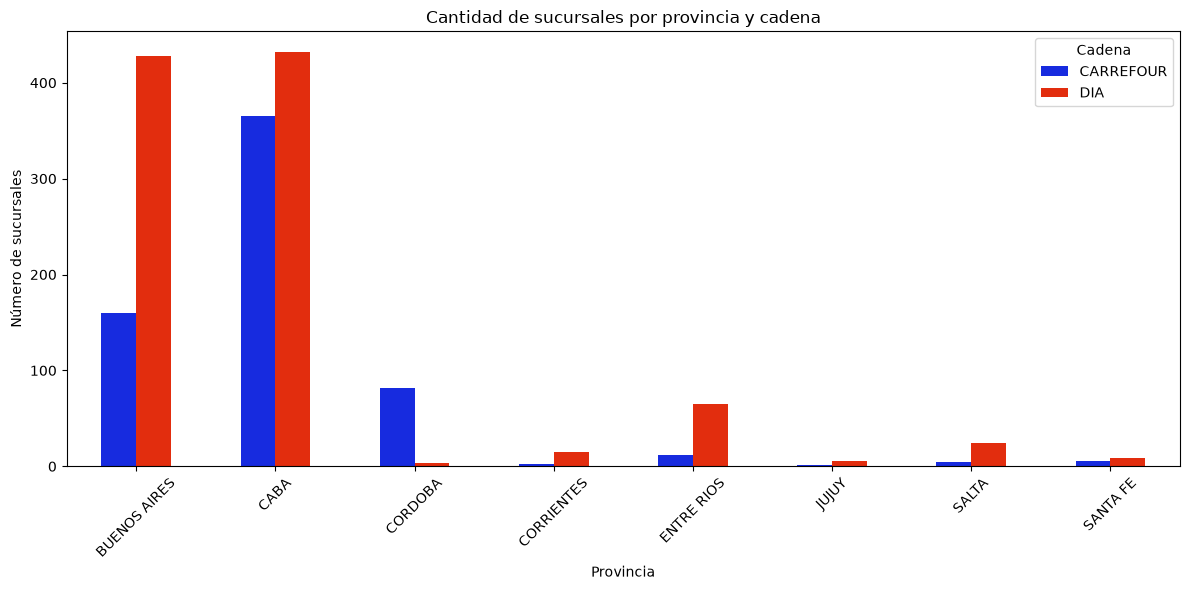

In [92]:
# Agrupación
sucursales_prov_cadena = (
    productos_comunes_8
    .groupby(['provincia', 'cadena'])['id_sucursal']
    .nunique()
    .reset_index()
)

# Pivot para graficar
pivot = sucursales_prov_cadena.pivot(index='provincia', columns='cadena', values='id_sucursal')

# Colores personalizados
colores = {
    'DIA': "#E22D0E",        # azul suave
    'CARREFOUR': "#172BDF"   # naranja tierra
}

# Gráfico
pivot.plot(kind='bar', figsize=(12,6), color=[colores[c] for c in pivot.columns])
plt.title('Cantidad de sucursales por provincia y cadena')
plt.xlabel('Provincia')
plt.ylabel('Número de sucursales')
plt.xticks(rotation=45)
plt.legend(title='Cadena')
plt.tight_layout()
plt.show()

